# Sales Data Analysis and Forecasting

## Objective
To analyze historical sales data, identify trends and patterns, and forecast future sales revenue.
This project helps businesses make data-driven decisions related to inventory and marketing.


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
df = pd.read_csv("data/sales_data.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.shape

(1000, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [6]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [9]:
# Convert Order Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Check missing values
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [23]:
df = df.dropna(subset=['Total Amount'])

In [24]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month Name'] = df['Date'].dt.month_name()
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month,Month Name
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,11,November
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2,February
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,1,January
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,5,May
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,5,May


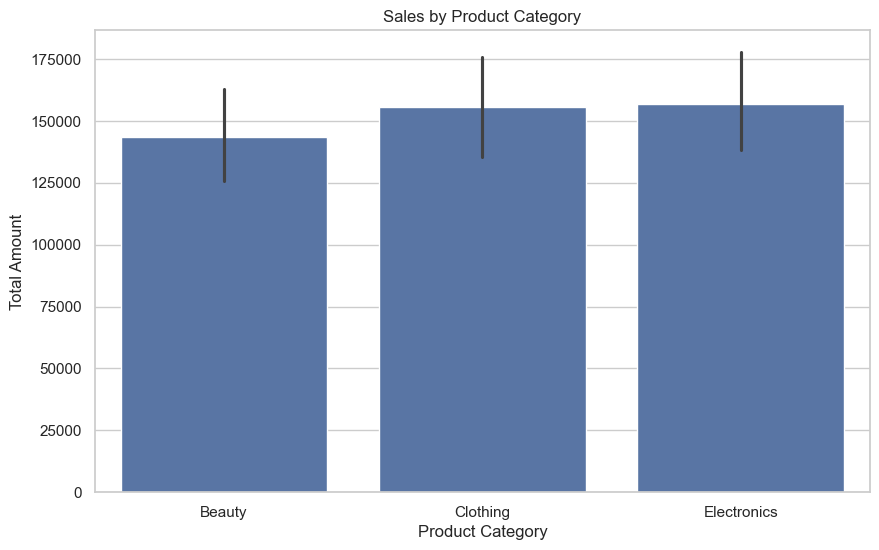

In [25]:
sns.barplot(
    x='Product Category',
    y='Total Amount',
    data=df,
    estimator=sum
)
plt.title("Sales by Product Category")
plt.show()

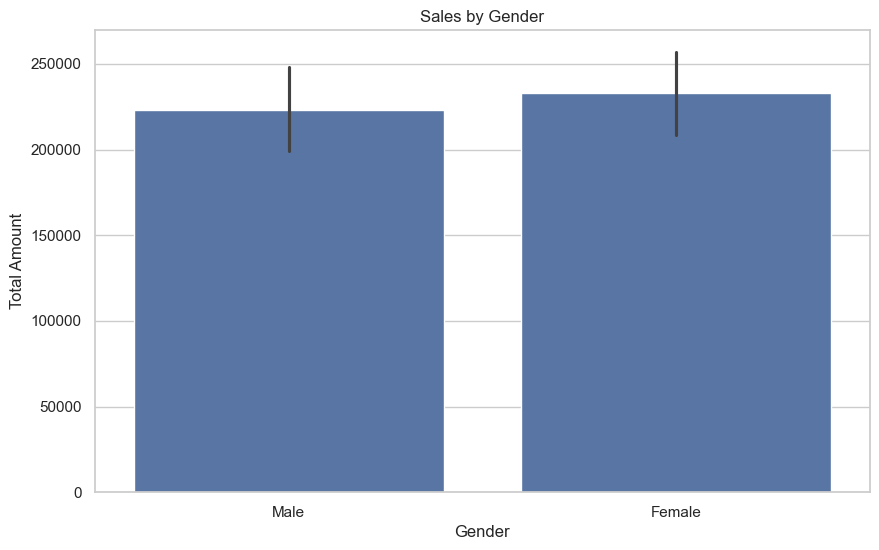

In [26]:
sns.barplot(
    x='Gender',
    y='Total Amount',
    data=df,
    estimator=sum
)
plt.title("Sales by Gender")
plt.show()


In [27]:
daily_sales = df.groupby('Date')['Total Amount'].sum().reset_index()
daily_sales.head()

,Date,Total Amount
0,2023-01-01,3600
1,2023-01-02,1765
2,2023-01-03,600
3,2023-01-04,1240
4,2023-01-05,1100


In [29]:
monthly_sales = (
    daily_sales
    .set_index('Date')
    .resample('M')
    .sum()
    .reset_index()
)
monthly_sales.head()

,Date,Total Amount
0,2023-01-31,35450
1,2023-02-28,44060
2,2023-03-31,28990
3,2023-04-30,33870
4,2023-05-31,53150


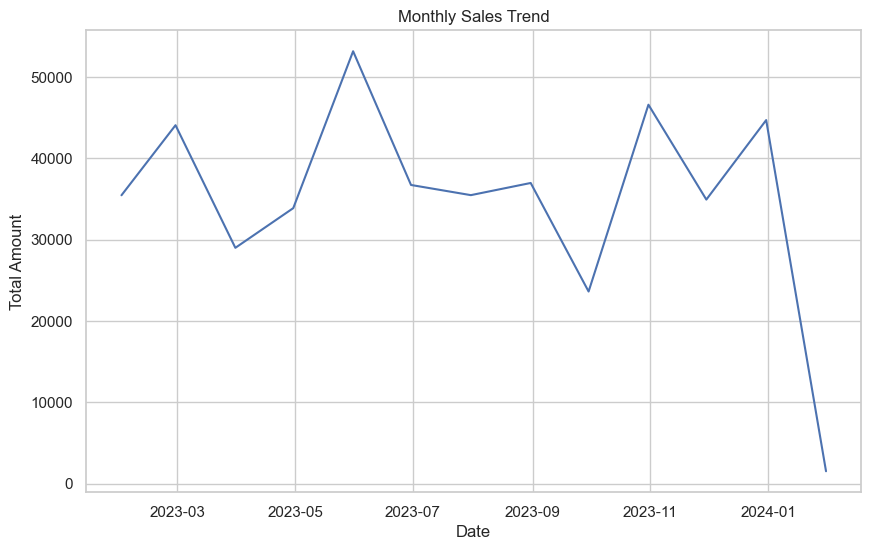

In [30]:
plt.plot(monthly_sales['Date'], monthly_sales['Total Amount'])
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Amount")
plt.show()

In [32]:
monthly_sales['Time Index'] = range(len(monthly_sales))

X = monthly_sales[['Time Index']]
y = monthly_sales['Total Amount']

In [33]:
model = LinearRegression()
model.fit(X, y)

monthly_sales['Forecast'] = model.predict(X)

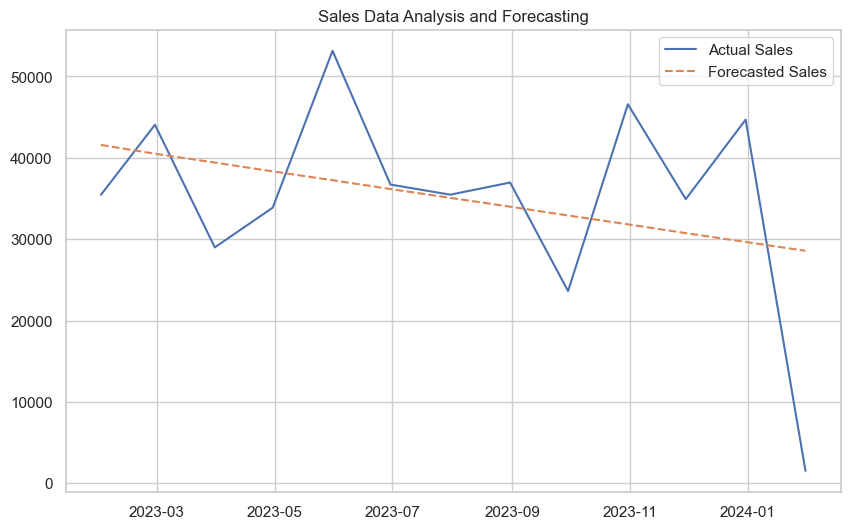

In [34]:
plt.plot(monthly_sales['Date'], monthly_sales['Total Amount'], label='Actual Sales')
plt.plot(monthly_sales['Date'], monthly_sales['Forecast'], label='Forecasted Sales', linestyle='--')

plt.legend()
plt.title("Sales Data Analysis and Forecasting")
plt.show()

## Conclusion
The analysis identified clear sales patterns across time and product categories.
Using a simple linear regression model, future sales trends were forecasted successfully.
These insights can help businesses make informed decisions related to inventory and revenue planning.
